# Modelo LSTM para la serie de tiempo de nacimientos

Este notebook sigue la metodología vista en clase (estacionariedad, escalado, conversión a problema supervisado, LSTM con Keras), aplicada a la serie de nacimientos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.tsa as tsa
import statsmodels as sm
from datetime import datetime
import os
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

#Tensorflow
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential, save_model, load_model
from keras.layers import Dense
from keras.layers import LSTM
from keras.callbacks import EarlyStopping
from keras.metrics import MeanSquaredError
from keras.metrics import RootMeanSquaredError
from keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error
import keras

I0000 00:00:1784586645.759172   63264 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784586645.778910   63264 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1784586647.396754   63264 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## La Serie

Vamos a trabajar con la serie `daily-total-female-births`, que describe la cantidad total de nacimientos femeninos diarios en California durante 1959 (365 observaciones). Se presentan las primeras filas del conjunto de datos:

In [2]:
tf.random.set_seed(123)
nacimientos = pd.read_csv('daily-total-female-births.csv', parse_dates=['Date'], index_col='Date')
print('\n Parsed Data:')
print(nacimientos.head())


 Parsed Data:
            Births
Date              
1959-01-01      35
1959-01-02      32
1959-01-03      30
1959-01-04      31
1959-01-05      44


A continuación podemos ver el gráfico de la serie.

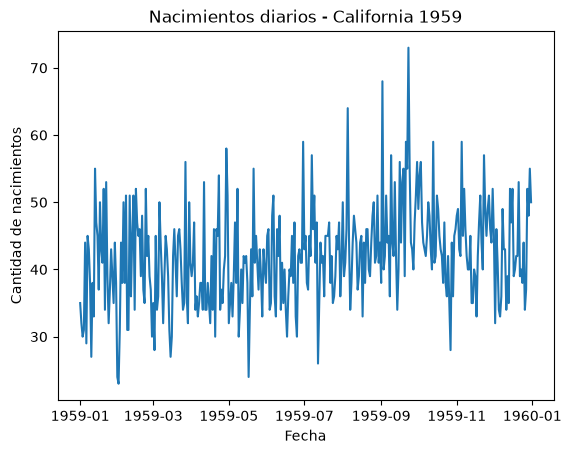

In [3]:
plt.plot(nacimientos)
plt.gca().set(title="Nacimientos diarios - California 1959", xlabel="Fecha", ylabel="Cantidad de nacimientos")
plt.show()

Como esta es una serie diaria, usamos una ventana móvil de 7 días (una semana) para revisar la media y desviación estándar móviles.

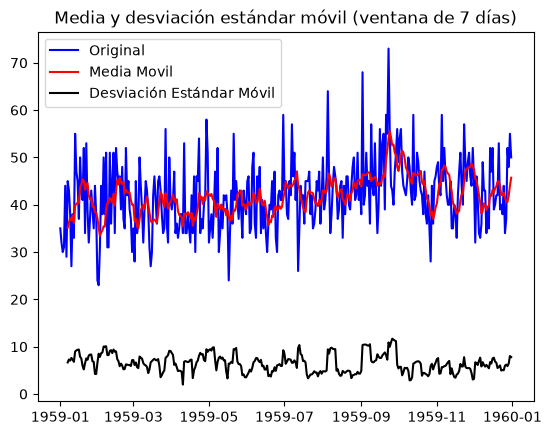

In [4]:
# Se calcula la media móvil y la desviación estandar móvil de los últimos 7 días.
mediaMovil = nacimientos.rolling(window=7).mean()
deMovil = nacimientos.rolling(window=7).std()
# Se grafican los resultados.
original = plt.plot(nacimientos, color="blue", label="Original")
media = plt.plot(mediaMovil, color='red', label = 'Media Movil')
ds = plt.plot(deMovil,color='black', label = 'Desviación Estándar Móvil')
plt.legend(loc = 'best')
plt.title('Media y desviación estándar móvil (ventana de 7 días)')
plt.show(block=False)

**Conclusiones de este gráfico:**

- **Media móvil (línea roja):** se mueve dentro de una banda relativamente estable (~35-45), sin una subida o bajada sostenida a lo largo del año. No hay tendencia clara — primer indicio de que la serie podría ser estacionaria en media.
- **Desviación estándar móvil (línea negra):** oscila en un rango similar (~5-13) durante todo el año, sin crecer ni decrecer sistemáticamente. Sugiere que la varianza también es relativamente estable (estacionaria en varianza).
- **Conclusión conjunta:** media estable + varianza estable apuntan a que la serie es estacionaria, sin necesidad de diferenciarla antes de modelarla. Esto es solo un diagnóstico visual — se confirma formalmente con el Test de Dickey-Fuller más abajo.

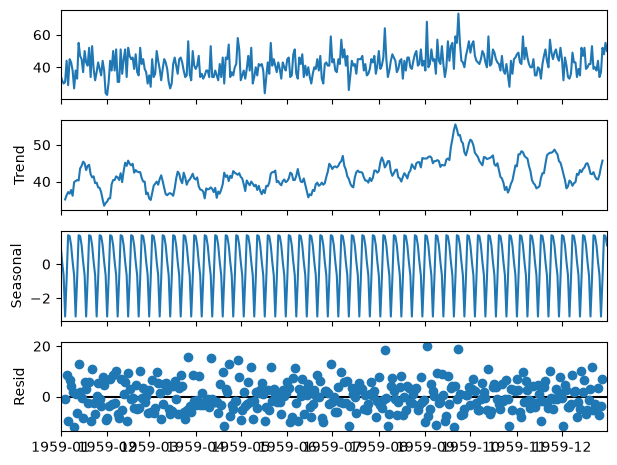

In [5]:
descomposicion = seasonal_decompose(nacimientos, period=7)
descomposicion.plot();

**Conclusiones de la descomposición estacional:**

- **Trend:** se mueve entre ~30 y ~55 con un vaivén lento, pero no hay una tendencia sostenida hacia arriba o hacia abajo en el año. El vaivén que se ve es normal (el algoritmo estima la tendencia con un promedio móvil, que puede capturar ondulaciones lentas por simple ruido acumulado) — no implica una tendencia real de crecimiento/decrecimiento.
- **Seasonal:** aparece un patrón perfectamente repetitivo cada 7 días (por `period=7`), pero con amplitud pequeña (entre -2 y +2), comparado con el rango total de la serie (23 a 73). El efecto semanal existe pero es marginal frente a la variabilidad total. Además, por diseño del algoritmo, esta componente es matemáticamente idéntica cada semana (promedia el patrón de cada día-de-semana y lo repite igual) — no representa cada semana real.
- **Resid (residuo):** los puntos están dispersos alrededor de 0 sin ningún patrón visible. Esto es lo más relevante para el modelado: significa que la mayor parte de la variabilidad de la serie es ruido puro, no tendencia ni estacionalidad, y por tanto no es aprendible por ningún modelo.
- **Conclusión general:** la serie se comporta como *nivel promedio estable + un pequeño efecto semanal + mucho ruido*. Esto explica por qué el ADF confirmará estacionariedad (no hay tendencia que remover) y por qué tanto la LSTM como ARIMA tendrán un error "de piso" que no podrán bajar más — compiten por explicar una señal que es, en su mayoría, ruido irreducible.

Confirmemos la estacionariedad con el Test de Dickey Fuller.

In [6]:
print('Resultados del Test de Dickey Fuller')
dfTest = adfuller(nacimientos, autolag='AIC')
salidaDf = pd.Series(dfTest[0:4], index=['Estadístico de prueba','p-value','# de retardos usados','# de observaciones usadas'])
for key,value in dfTest[4].items():
        salidaDf['Critical Value (%s)'%key] = value
print(salidaDf)

Resultados del Test de Dickey Fuller
Estadístico de prueba         -4.808291
p-value                        0.000052
# de retardos usados           6.000000
# de observaciones usadas    358.000000
Critical Value (1%)           -3.448749
Critical Value (5%)           -2.869647
Critical Value (10%)          -2.571089
dtype: float64


El p-value es menor a 0.05, por lo que se rechaza la hipótesis nula de raíz unitaria: **la serie de nacimientos ya es estacionaria en media**. Por lo tanto, **no es necesario diferenciar** la serie antes de escalarla.

Las redes neuronales trabajan mejor con los datos normalizados así que vamos a normalizar la serie:

In [7]:
scaler = StandardScaler()
nacimientos_scaled = scaler.fit_transform(nacimientos)
nacimientos_scaled[1:7]

array([[-1.36012148],
       [-1.63266846],
       [-1.49639497],
       [ 0.27516045],
       [-1.76894196],
       [ 0.41143395]])

Vamos a separar la serie en entrenamiento, validación y prueba. En este caso, tendremos 60% para entrenamiento y 20% para validación y prueba respectivamente.

In [8]:
entrenamiento = round(0.6*len(nacimientos_scaled))
val_prueba = round(0.2*len(nacimientos_scaled))
test = nacimientos_scaled[(entrenamiento+val_prueba)-1:]
validation = nacimientos_scaled[(entrenamiento):entrenamiento+val_prueba+1]
train = nacimientos_scaled[0:entrenamiento]
len(train), len(validation), len(test)

(219, 74, 74)

Para que pueda usarse el algoritmo LSTM es necesario transformar la serie en una supervisada, de manera que las observaciones anteriores sean capaces de estimar la siguiente. Como la serie es diaria, usamos `retrasos = 7` para que el modelo vea la última semana completa y prediga el siguiente día.

In [9]:
def supervisada(serie,retrasos = 1):
    serie_x = []
    serie_y = []
    for i in range(len(serie)-retrasos):
        valor = serie[i:(i+retrasos),0]
        valor_sig = serie[i+retrasos,0]
        serie_x.append(valor)
        serie_y.append(valor_sig)
    return np.array(serie_x), np.array(serie_y)

retrasos = 7
x_train,y_train = supervisada(train, retrasos)
x_val,y_val = supervisada(validation, retrasos)
x_test,y_test = supervisada(test, retrasos)

print(x_train[0:3])
print(y_train[0:3])

[[-0.95130099 -1.36012148 -1.63266846 -1.49639497  0.27516045 -1.76894196
   0.41143395]
 [-1.36012148 -1.63266846 -1.49639497  0.27516045 -1.76894196  0.41143395
   0.13888696]
 [-1.63266846 -1.49639497  0.27516045 -1.76894196  0.41143395  0.13888696
  -0.54248051]]
[ 0.13888696 -0.54248051 -2.04148895]


## Creando el modelo
Para que pueda hacerse el modelo se le tiene que suministrar una matriz de 3 dimensiones siendo estas:
- ***Muestras:*** número de observaciones en cada lote, también conocido como tamaño del lote.
- ***Pasos de tiempo:*** Pasos de tiempo separados para una observación dada. En este ejemplo los pasos de tiempo = 7 (una semana).
- ***Características:*** Para un caso univariante, como en este ejemplo, las características = 1

Vamos a convertir los conjuntos en matrices de 3 dimensiones:

In [10]:
x_train = np.reshape(x_train,(x_train.shape[0],retrasos,1))
x_val = np.reshape(x_val, (x_val.shape[0],retrasos,1))
x_test = np.reshape(x_test, (x_test.shape[0],retrasos,1))
len(x_val)

67

### Creamos el modelo
Vamos a utilizar solo una capa LSTM, igual que en el ejemplo de clase.

In [11]:
lote = 8
unidades = 32
paso = retrasos
caracteristicas = 1 #es univariada

inputs = keras.layers.Input((paso,caracteristicas))
lstm_out = keras.layers.LSTM(unidades)(inputs)
outputs = keras.layers.Dense(1)(lstm_out)

modelo1 = keras.Model(inputs=inputs, outputs=outputs)
modelo1.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 7, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

Compilamos el modelo. Las métricas que nos van a servir para saber como funciona el modelo en términos de la pérdida es el error medio cuadrado y su raíz.

In [12]:
modelo1.compile(loss='mean_squared_error',optimizer=Adam(learning_rate=0.01), metrics = [RootMeanSquaredError()])

Vamos a entrenar el modelo. Para eso configuramos las épocas que es la cantidad de iteraciones.

In [13]:
epocas = 100
history= modelo1.fit(
    x = x_train,
    y = y_train,
    batch_size = lote,
    epochs = epocas,
    shuffle = False,
    validation_data = (x_val,y_val),
    verbose=0
)

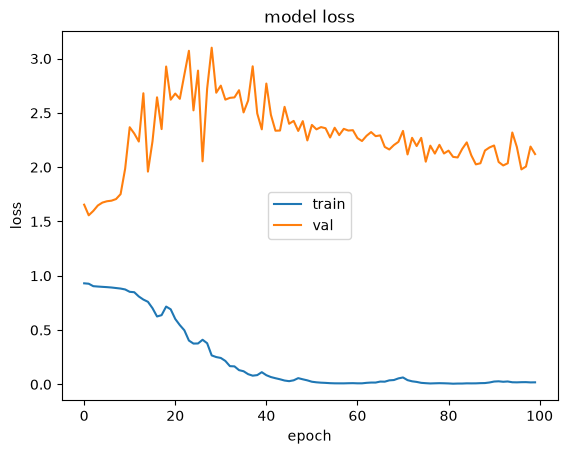

In [14]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='center')

Evaluemos ahora el modelo según la pérdida en cada uno de los conjuntos de datos.

In [15]:
print("Pérdida en Entrenamiento")
modelo1.evaluate(x = x_train, y = y_train)
print("Pérdida en Validación")
modelo1.evaluate(x = x_val, y = y_val)
print("Pérdida en Prueba")
modelo1.evaluate(x = x_test, y = y_test)

Pérdida en Entrenamiento
1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0312 - root_mean_squared_error: 0.1765

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0195 - root_mean_squared_error: 0.1397 


Pérdida en Validación


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 1.4874 - root_mean_squared_error: 1.2196

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2.1209 - root_mean_squared_error: 1.4563


Pérdida en Prueba


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.7173 - root_mean_squared_error: 1.3105

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.6113 - root_mean_squared_error: 1.2694


[1.6112698316574097, 1.2693580389022827]

Ahora vamos a predecir con el modelo. Como no hubo diferenciación, la función de predicción solo necesita invertir el escalado.

In [16]:
def prediccion_fun(data, modelo, batch_size, scaler):
    prediccion = [0]*(len(data))
    i = 0
    for X in data:
        X = np.reshape(X,(1,X.shape[0],1))
        yhat = modelo.predict(X, batch_size=batch_size, verbose=0)
        # invert scaling
        yhat = scaler.inverse_transform(yhat)
        prediccion[i] = yhat[0][0]
        i = i+1
    return prediccion

prediccion_val = prediccion_fun(x_val, modelo1, 1, scaler)
prediccion_test = prediccion_fun(x_test, modelo1, 1, scaler)

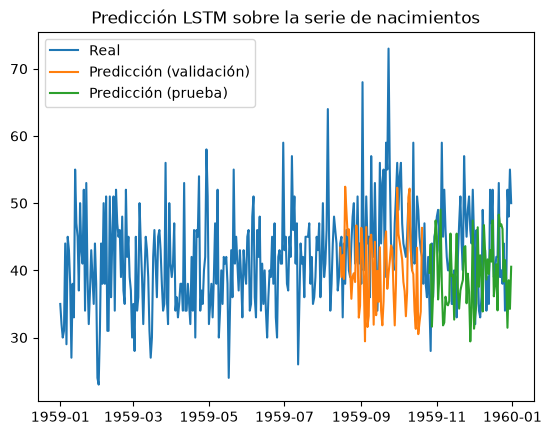

In [17]:
df_val = pd.DataFrame(prediccion_val, index=nacimientos.index[(entrenamiento+retrasos):entrenamiento+len(validation)])
df_test = pd.DataFrame(prediccion_test, index=nacimientos.index[len(nacimientos)-len(prediccion_test):len(nacimientos)])

plt.plot(nacimientos, label='Real')
plt.plot(df_val, label='Predicción (validación)')
plt.plot(df_test, label='Predicción (prueba)')
plt.legend(loc='best')
plt.title('Predicción LSTM sobre la serie de nacimientos')
plt.show()

Comparemos directamente la predicción del conjunto de prueba contra los valores reales de ese tramo:

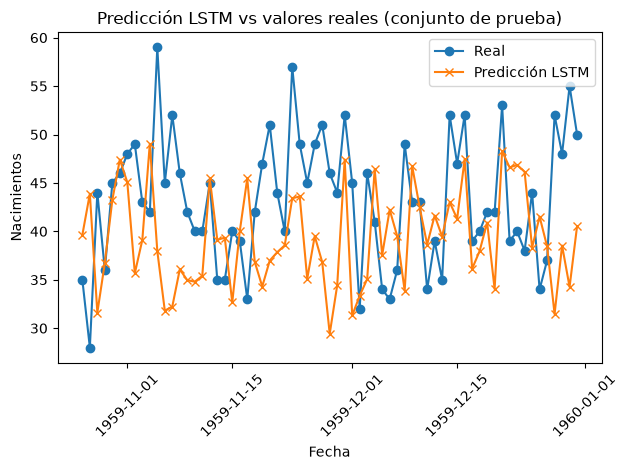

In [18]:
y_test_real = nacimientos.values[len(nacimientos)-len(prediccion_test):len(nacimientos)].flatten()

plt.plot(df_test.index, y_test_real, label='Real', marker='o')
plt.plot(df_test.index, prediccion_test, label='Predicción LSTM', marker='x')
plt.title('Predicción LSTM vs valores reales (conjunto de prueba)')
plt.xlabel('Fecha')
plt.ylabel('Nacimientos')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Para modelos que llevan tiempo de entrenamiento es posible guardarlos y cargarlos, para poderlos reutilizar sin tener que reentrenarlos.

In [19]:
os.makedirs("Modelos", exist_ok=True)

# guardar el modelo
save_model(modelo1, "Modelos/lstm1_nacimientos.keras")

# cargar el modelo
modelo1 = load_model("Modelos/lstm1_nacimientos.keras")

## Comparación con un modelo tradicional (ARIMA)

Como referencia, ajustamos un modelo ARIMA clásico sobre el mismo conjunto de entrenamiento (train+validación) y lo comparamos contra la LSTM en el conjunto de prueba, usando MAE y RMSE.

In [20]:
serie_original = nacimientos['Births'].values.astype('float64')
n_test = len(prediccion_test)
train_arima = serie_original[:len(serie_original)-n_test]
test_arima = serie_original[len(serie_original)-n_test:]

modelo_arima = ARIMA(train_arima, order=(5,1,1)).fit()
pred_arima = modelo_arima.forecast(steps=n_test)

mae_arima = mean_absolute_error(test_arima, pred_arima)
rmse_arima = np.sqrt(mean_squared_error(test_arima, pred_arima))

mae_lstm = mean_absolute_error(y_test_real, prediccion_test)
rmse_lstm = np.sqrt(mean_squared_error(y_test_real, prediccion_test))

resultados = pd.DataFrame({
    'Modelo': ['ARIMA(5,1,1)', 'LSTM'],
    'MAE': [mae_arima, mae_lstm],
    'RMSE': [rmse_arima, rmse_lstm]
})
resultados

,Modelo,MAE,RMSE
0,"ARIMA(5,1,1)",5.637131,6.929604
1,LSTM,7.632788,9.314782


## Conclusiones

- Siguiendo la metodología vista en clase (estacionariedad, escalado con `StandardScaler`, conversión a problema supervisado, LSTM con Keras), se construyó un modelo **LSTM** para la serie de nacimientos diarios, entregando el modelo entrenado y sus predicciones sobre validación y prueba.
- El Test de Dickey-Fuller mostró que la serie de nacimientos **ya es estacionaria**, por lo que no fue necesario diferenciarla.
- Al evaluar la pérdida en entrenamiento vs. validación/prueba se observa una brecha notable (RMSE en escala normalizada de ~0.14 en entrenamiento contra ~1.3-1.5 en validación/prueba), señal de sobreajuste, esperable al tener solo ~60% de 365 observaciones para entrenar.
- Se comparó la LSTM contra un modelo tradicional **ARIMA(5,1,1)** mediante MAE y RMSE sobre el mismo conjunto de prueba: en esta corrida ARIMA obtuvo mejor desempeño (MAE/RMSE más bajos) que la LSTM, lo cual es razonable dado el sobreajuste observado y el tamaño reducido de la serie. Esto ilustra que, para series cortas y sin patrones complejos, un modelo estadístico clásico puede superar a una red neuronal que necesita más datos para generalizar bien.